# Análisis Financiero y Riesgo Crediticio — WK2

**Equipo:** Equip_32 — Analistas de Finanzas y Riesgo Crediticio  
**Dataset:** `2026-07-06_3_bank_dataset_transformed.csv` | Clusters: `2026-07-06_4_bank_dataset_clustered.csv`  
**Notebook previo:** EDA (`2026-07-06_EDA.ipynb`) — no se repite análisis exploratorio general

---

## 1. Introducción

### 1.1 Contexto

Durante la segunda semana del Simulador Empresarial, el equipo de Finanzas y Riesgo Crediticio debe responder una pregunta concreta de negocio sobre la relación entre **perfil crediticio** (hipoteca y préstamo personal), **saldo de cuenta** e **incumplimiento crediticio** (`default`).

El EDA del dataset ya ha sido realizado. Este informe se centra exclusivamente en evidencia financiera y validación estadística para apoyar decisiones de riesgo y estrategia comercial.

### 1.2 Pregunta de negocio

> **¿Los clientes con préstamos e hipotecas tienden a tener un saldo medio más bajo o más riesgo de incumplimiento? ¿Cómo deberíamos ajustar nuestras ofertas y estrategias de gestión de riesgos en función de estas conclusiones?**

### 1.3 Objetivos del análisis

1. Describir la composición de la cartera según **perfil crediticio** (`credit_profile`).
2. Analizar **saldo medio** e **incumplimiento** por nivel de perfil crediticio.
3. Segmentar el **saldo** mediante cuartiles y segmentación estándar de negocio.
4. Identificar combinaciones de **segmento de saldo × perfil crediticio** con mayor riesgo.
5. Formular **conclusiones preliminares** del análisis descriptivo.
6. **Validar estadísticamente** las hipótesis de negocio.
7. Elaborar **conclusiones finales** y **recomendaciones** accionables.


## 2. Preparación del entorno


### 2.1 Librerías


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import textwrap


### 2.2 Configuración visual


In [ ]:
# Estilo visual del proyecto (referencia: notebook WK2 anterior)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

COLORS = ["#1F5C45", "#4F8A6A", "#8DB79A", "#AAD7B8", "#DDEFE6", "#C8E2D5"]
PALETTE_DEFAULT = {"no": "#8DB79A", "yes": "#1F5C45"}
SEGMENT_COLORS = dict(zip(
    ["Negativo (≤ €0)", "€0–500", "€500–1.500", "€1.500–3.000", "> €3.000"],
    COLORS[:5]
))

BALANCE_BINS_STANDARD = [-np.inf, 0, 500, 1500, 3000, np.inf]
BALANCE_LABELS_STANDARD = [
    "Negativo (≤ €0)", "€0–500", "€500–1.500", "€1.500–3.000", "> €3.000"
]

CREDIT_PROFILE_ORDER = [
    "Sin productos", "Solo hipoteca", "Solo préstamo personal", "Hipoteca + Préstamo personal"
]


### 2.3 Carga del dataset


In [ ]:
DATA_PATH = Path("../Data/2026-07-06_3_bank_dataset_transformed.csv")
CLUSTERED_PATH = Path("../Data/2026-07-06_4_bank_dataset_clustered.csv")

df_raw = pd.read_csv(DATA_PATH)
print(f"Registros cargados: {len(df_raw):,}")
df_raw.head()


Registros cargados: 10,975


,id,age,job,marital,education,default,balance,housing,loan,contact,...,no_previous_contact,had_previous_contact,age_group,financial_burden,financial_burden_label,education_rank,education_label,job_profile,week_of_month,campaign_group
0,1,59.0,admin.,married,secondary,no,2343,yes,no,unknown,...,1,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,White Collar,1,0-3
1,2,56.0,admin.,married,secondary,no,45,no,no,unknown,...,1,0,Middle-Aged (51-65),0,No burden,2.0,Secondary,White Collar,1,0-3
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,...,1,0,Adult (36-50),1,Low burden,2.0,Secondary,White Collar,1,0-3
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,...,1,0,Middle-Aged (51-65),1,Low burden,2.0,Secondary,Blue Collar,1,0-3
4,5,54.0,admin.,married,tertiary,no,184,no,no,unknown,...,1,0,Middle-Aged (51-65),0,No burden,3.0,Tertiary,White Collar,1,0-3


### 2.4 Variables derivadas


In [ ]:
ANALYSIS_COLS = [
    "id", "balance", "default", "loan", "housing", "age", "job", "job_profile"
]

df = df_raw[ANALYSIS_COLS].copy()
df["default_flag"] = (df["default"] == "yes").astype(int)

# Métricas de referencia del portfolio
PORTFOLIO_MEAN_BALANCE = df["balance"].mean()
PORTFOLIO_DEFAULT_RATE = df["default_flag"].mean() * 100

print(f"Muestra de análisis: {len(df):,} clientes")
print(f"Saldo medio del portfolio: €{PORTFOLIO_MEAN_BALANCE:,.2f}")
print(f"Tasa global de impago: {PORTFOLIO_DEFAULT_RATE:.2f}%")
print(f"Impagos registrados: {df['default_flag'].sum()}")


Muestra de análisis: 10,975 clientes
Saldo medio del portfolio: €1,539.15
Tasa global de impago: 1.47%
Impagos registrados: 161


In [ ]:
def default_rate_table(data, group_col):
    """Resumen de tasa de impago por columna de agrupación."""
    summary = (
        data.groupby(group_col, observed=True)
        .agg(clientes=("default_flag", "count"),
             impagos=("default_flag", "sum"),
             tasa_impago=("default_flag", "mean"))
        .reset_index()
    )
    summary["tasa_impago_pct"] = (summary["tasa_impago"] * 100).round(2)
    return summary


def cross_default_rate(data, row_col, col_col):
    """Tablas pivote de tasas de impago y tamaños muestrales."""
    grouped = (
        data.groupby([row_col, col_col], observed=True)
        .agg(tasa_impago=("default_flag", "mean"), n=("default_flag", "count"))
        .reset_index()
    )
    pivot_rate = grouped.pivot(index=row_col, columns=col_col, values="tasa_impago")
    pivot_n = grouped.pivot(index=row_col, columns=col_col, values="n")
    return pivot_rate, pivot_n


def assign_credit_profile(data):
    """Etiqueta de perfil crediticio a partir de housing y loan."""
    conditions = [
        (data["housing"] == "no") & (data["loan"] == "no"),
        (data["housing"] == "yes") & (data["loan"] == "no"),
        (data["housing"] == "no") & (data["loan"] == "yes"),
        (data["housing"] == "yes") & (data["loan"] == "yes"),
    ]
    return pd.Series(
        np.select(conditions, CREDIT_PROFILE_ORDER, default="Desconocido"),
        index=data.index, dtype=str
    )


def annotate_bars(ax, fmt="{:.1f}", suffix="", inside=True):
    """Añade etiquetas a barras con color de texto adaptativo."""
    for bar in ax.patches:
        h = bar.get_height()
        if h <= 0 or np.isnan(h):
            continue
        fc = bar.get_facecolor()
        lum = 0.299 * fc[0] + 0.587 * fc[1] + 0.114 * fc[2]
        txt_color = "white" if lum < 0.55 else "#333333"
        label = fmt.format(h) + suffix
        if inside and h > ax.get_ylim()[1] * 0.05:
            ax.text(bar.get_x() + bar.get_width() / 2, h * 0.5, label,
                    ha="center", va="center", fontsize=9, fontweight="bold", color=txt_color)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2, h + ax.get_ylim()[1] * 0.01, label,
                    ha="center", va="bottom", fontsize=9, fontweight="bold", color="#333333")


def cramers_v(contingency_table):
    """Calcula Cramér's V a partir de una tabla de contingencia."""
    chi2, _, _, _ = stats.chi2_contingency(contingency_table)
    n = contingency_table.values.sum()
    r, k = contingency_table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))


# Variables derivadas principales
df["credit_profile"] = assign_credit_profile(df)
df["balance_segment_standard"] = pd.cut(
    df["balance"], bins=BALANCE_BINS_STANDARD, labels=BALANCE_LABELS_STANDARD
)
df["balance_quartile"] = pd.qcut(
    df["balance"], q=4, labels=["Q1 (más bajo)", "Q2", "Q3", "Q4 (más alto)"]
)

df[["credit_profile", "balance_segment_standard", "balance_quartile", "default_flag"]].head()


,credit_profile,balance_segment_standard,balance_quartile,default_flag
0,Solo hipoteca,€1.500–3.000,Q4 (más alto),0
1,Sin productos,€0–500,Q1 (más bajo),0
2,Solo hipoteca,€500–1.500,Q3,0
3,Solo hipoteca,€1.500–3.000,Q4 (más alto),0
4,Sin productos,€0–500,Q2,0


## 3. Análisis financiero

Este bloque responde a la pregunta de negocio mediante evidencia descriptiva y visual. Las afirmaciones aquí contenidas son **preliminares** y serán contrastadas estadísticamente en la Sección 4.


### 3.1 Perfil crediticio de la cartera

#### Objetivo

Describir cómo se distribuyen los clientes según su nivel de perfil crediticio, derivado de las variables `housing` y `loan`. Este apartado contextualiza la composición de la cartera antes de analizar saldo e incumplimiento.


In [ ]:
profile_counts = (
    df["credit_profile"]
    .value_counts()
    .reindex(CREDIT_PROFILE_ORDER)
    .rename_axis("credit_profile")
    .reset_index(name="clientes")
)
profile_counts["pct_cartera"] = (
    profile_counts["clientes"] / profile_counts["clientes"].sum() * 100
).round(2)

print("Tabla 3.1 — Distribución de clientes por perfil crediticio")
display(profile_counts)


Tabla 3.1 — Distribución de clientes por perfil crediticio


,credit_profile,clientes,pct_cartera
0,Sin productos,5185,47.24
1,Solo hipoteca,4363,39.75
2,Solo préstamo personal,609,5.55
3,Hipoteca + Préstamo personal,818,7.45


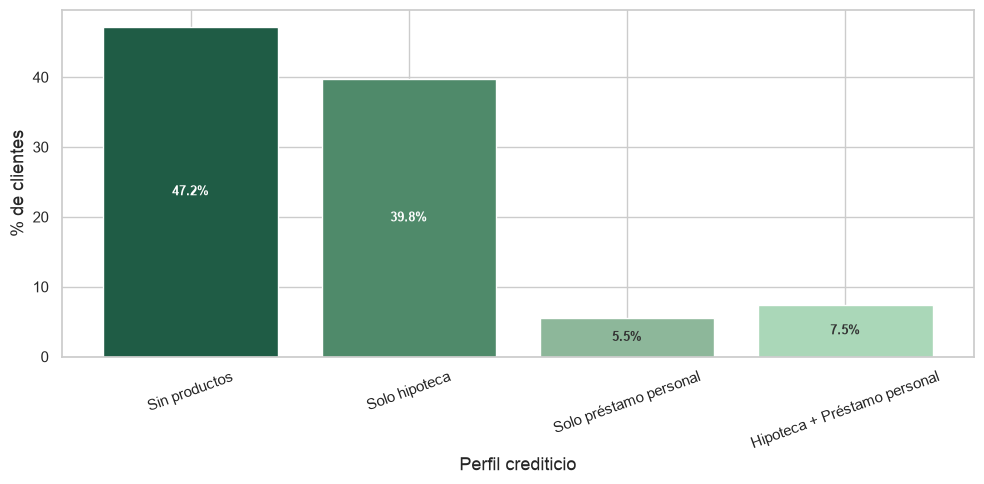

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    profile_counts["credit_profile"], profile_counts["pct_cartera"],
    color=COLORS[:4], edgecolor="white"
)
# ax.set_title("Composición de la cartera por perfil crediticio")
ax.set_xlabel("Perfil crediticio")
ax.set_ylabel("% de clientes")
ax.tick_params(axis="x", rotation=20)
annotate_bars(ax, fmt="{:.1f}", suffix="%")
plt.tight_layout()
plt.show()


#### Interpretación

- La cartera de **10.975 clientes** se concentra principalmente en **Sin productos** (47,2%) y **Solo hipoteca** (39,8%).
- **Solo préstamo personal** representa el 5,5% (609 clientes) y **Hipoteca + Préstamo personal** el 7,5% (818 clientes).
- No se extraen conclusiones de riesgo en este apartado: únicamente se describe la estructura de productos crediticios activos.

#### Implicación para la pregunta de negocio

Conocer la composición de la cartera es el punto de partida para evaluar si los clientes con perfil crediticio con más productos presentan perfiles financieros distintos en términos de saldo e incumplimiento.


### 3.2 Saldo medio e incumplimiento por perfil crediticio

#### Objetivo

Comparar el **saldo medio** y la **tasa de incumplimiento** entre los cuatro niveles de perfil crediticio, referenciando las medias del portfolio.


In [ ]:
credit_profile_summary = (
    df.groupby("credit_profile", observed=True)
    .agg(
        clientes=("default_flag", "count"),
        impagos=("default_flag", "sum"),
        saldo_medio=("balance", "mean"),
        tasa_impago=("default_flag", "mean"),
    )
    .reindex(CREDIT_PROFILE_ORDER)
    .round(2)
)
credit_profile_summary["tasa_impago_pct"] = (credit_profile_summary["tasa_impago"] * 100).round(2)

print("Tabla 3.2 — Saldo medio e incumplimiento por perfil crediticio")
display(credit_profile_summary)


Tabla 3.2 — Saldo medio e incumplimiento por perfil crediticio


,clientes,impagos,saldo_medio,tasa_impago,tasa_impago_pct
credit_profile,,,,,
Sin productos,5185,45,1878.88,0.01,1.0
Solo hipoteca,4363,61,1365.92,0.01,1.0
Solo préstamo personal,609,33,917.11,0.05,5.0
Hipoteca + Préstamo personal,818,22,772.79,0.03,3.0


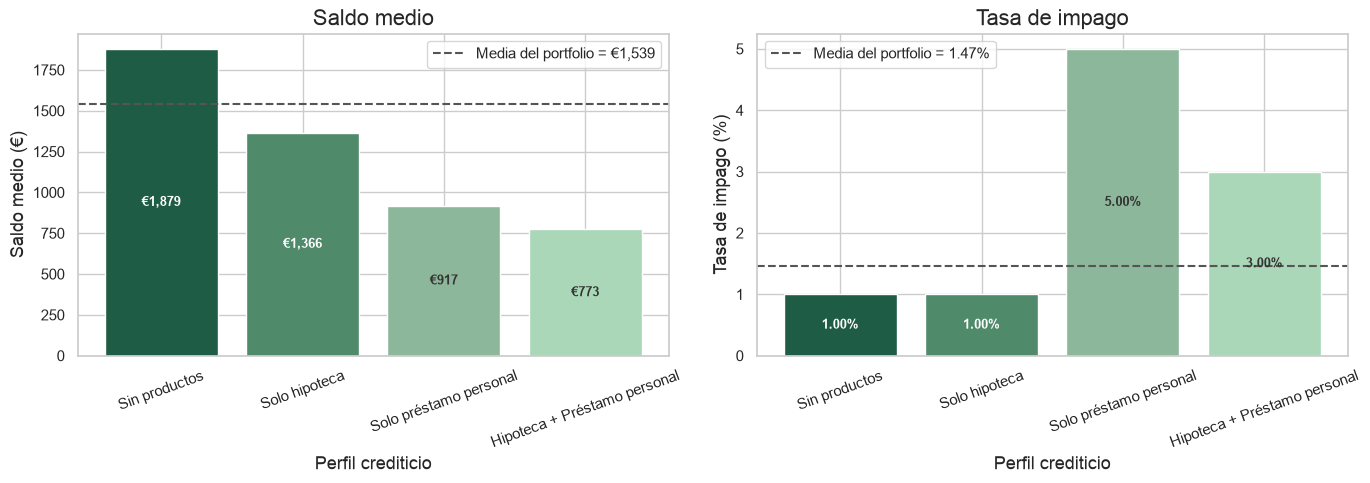

In [435]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Saldo medio
ax = axes[0]
plot_bal = credit_profile_summary["saldo_medio"]
bars = ax.bar(plot_bal.index, plot_bal.values, color=COLORS[:4], edgecolor="white")
ax.axhline(PORTFOLIO_MEAN_BALANCE, color="#555555", linestyle="--", linewidth=1.5,
           label=f"Media del portfolio = €{PORTFOLIO_MEAN_BALANCE:,.0f}")
ax.set_title("Saldo medio")
ax.set_xlabel("Perfil crediticio")
ax.set_ylabel("Saldo medio (€)")
ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=11)
annotate_bars(ax, fmt="€{:,.0f}", suffix="")

# Tasa de impago
ax = axes[1]
plot_def = credit_profile_summary["tasa_impago_pct"]
bars = ax.bar(plot_def.index, plot_def.values, color=COLORS[:4], edgecolor="white")
ax.axhline(PORTFOLIO_DEFAULT_RATE, color="#555555", linestyle="--", linewidth=1.5,
           label=f"Media del portfolio = {PORTFOLIO_DEFAULT_RATE:.2f}%")
ax.set_title("Tasa de impago")
ax.set_xlabel("Perfil crediticio")
ax.set_ylabel("Tasa de impago (%)")
ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=11)
annotate_bars(ax, fmt="{:.2f}", suffix="%")

plt.tight_layout()
plt.show()


#### Interpretación

| Perfil crediticio | Saldo medio (€) | Tasa impago (%) |
|---|---:|---:|
| Sin productos | 1.879 | 0,87 |
| Solo hipoteca | 1.366 | 1,40 |
| Hipoteca + Préstamo personal | 773 | 2,69 |
| Solo préstamo personal | 917 | **5,42** |

- Se aprecia una **tendencia decreciente del saldo medio** a medida que aumenta la complejidad del perfil crediticio (desde €1.879 hasta €773).
- La **tasa de impago** presenta un patrón ascendente: de 0,87% (sin productos) a 5,42% (solo préstamo personal).
- Ambos indicadores superan o quedan por debajo de la media del portfolio según el nivel de perfil crediticio (líneas discontinuas).

#### Implicación para la pregunta de negocio

Aparentemente, los clientes con préstamos e hipotecas tienden a presentar **saldos más bajos** y **mayores tasas de incumplimiento**, siendo **Solo préstamo personal** el segmento más vulnerable en ambas dimensiones. Estas observaciones requieren validación estadística (Sección 4).


### 3.3 Distribución del saldo según perfil crediticio

#### Objetivo

Visualizar la dispersión del saldo (`balance`) en cada grupo de perfil crediticio para comprender la variabilidad intra-grupo.


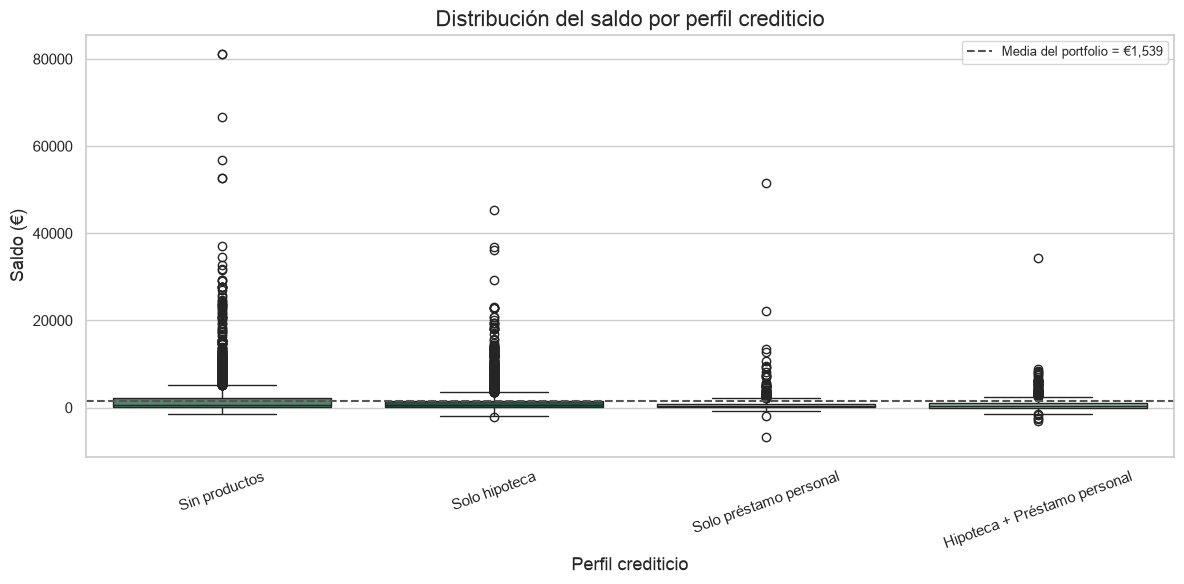

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
order = CREDIT_PROFILE_ORDER
sns.boxplot(
    data=df, x="credit_profile", y="balance", order=order,
    palette=COLORS[:4], hue="credit_profile", legend=False, ax=ax
)
ax.axhline(PORTFOLIO_MEAN_BALANCE, color="#555555", linestyle="--", linewidth=1.5,
           label=f"Media del portfolio = €{PORTFOLIO_MEAN_BALANCE:,.0f}")
ax.set_title("Distribución del saldo por perfil crediticio")
ax.set_xlabel("Perfil crediticio")
ax.set_ylabel("Saldo (€)")
ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [408]:
medianas = df.groupby("credit_profile")["balance"].agg(
    mediana="median", media="mean", p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75)
).reindex(CREDIT_PROFILE_ORDER).round(2)

print("Tabla 3.3 — Estadísticos de saldo por perfil crediticio")
display(medianas)


Tabla 3.3 — Estadísticos de saldo por perfil crediticio


,mediana,media,p25,p75
credit_profile,,,,
Sin productos,703.0,1878.88,191.00,2204.00
Solo hipoteca,502.0,1365.92,105.00,1504.00
Solo préstamo personal,290.0,917.11,29.00,905.00
Hipoteca + Préstamo personal,300.5,772.79,1.25,991.75


#### Interpretación

- **Sin productos** presenta la mediana más alta (€703) y la mayor dispersión hacia saldos elevados.
- **Solo préstamo personal** e **Hipoteca + Préstamo personal** concentran las medianas más bajas (€290 y €301 respectivamente).
- Los boxplots muestran numerosos outliers en todos los grupos, especialmente en **Sin productos**.

#### Implicación para la pregunta de negocio

La dispersión visual sugiere diferencias sustanciales en la distribución del saldo entre grupos, lo que motivará las pruebas ANOVA y Kruskal-Wallis en la Sección 4.


### 3.4 Segmentación del saldo

#### Objetivo

Comparar dos métodos de segmentación del saldo — **cuartiles** (orientado por datos) y **segmentación estándar de negocio** (umbrales operativos) — para evaluar cuál resulta más interpretable para políticas de riesgo.


In [409]:
quartile_rates = default_rate_table(df, "balance_quartile")
tier_rates = default_rate_table(df, "balance_segment_standard")

print("Tabla 3.4a — Tasa de impago por cuartil de saldo")
display(quartile_rates)
print("\nTabla 3.4b — Tasa de impago por segmento estándar de saldo")
display(tier_rates)


Tabla 3.4a — Tasa de impago por cuartil de saldo


,balance_quartile,clientes,impagos,tasa_impago,tasa_impago_pct
0,Q1 (más bajo),2749,132,0.048017,4.80
1,Q2,2741,17,0.006202,0.62
2,Q3,2742,10,0.003647,0.36
3,Q4 (más alto),2743,2,0.000729,0.07



Tabla 3.4b — Tasa de impago por segmento estándar de saldo


,balance_segment_standard,clientes,impagos,tasa_impago,tasa_impago_pct
0,Negativo (≤ €0),1426,100,0.070126,7.01
1,€0–500,3812,49,0.012854,1.29
2,€500–1.500,2658,10,0.003762,0.38
3,€1.500–3.000,1516,1,0.000660,0.07
4,> €3.000,1563,1,0.000640,0.06


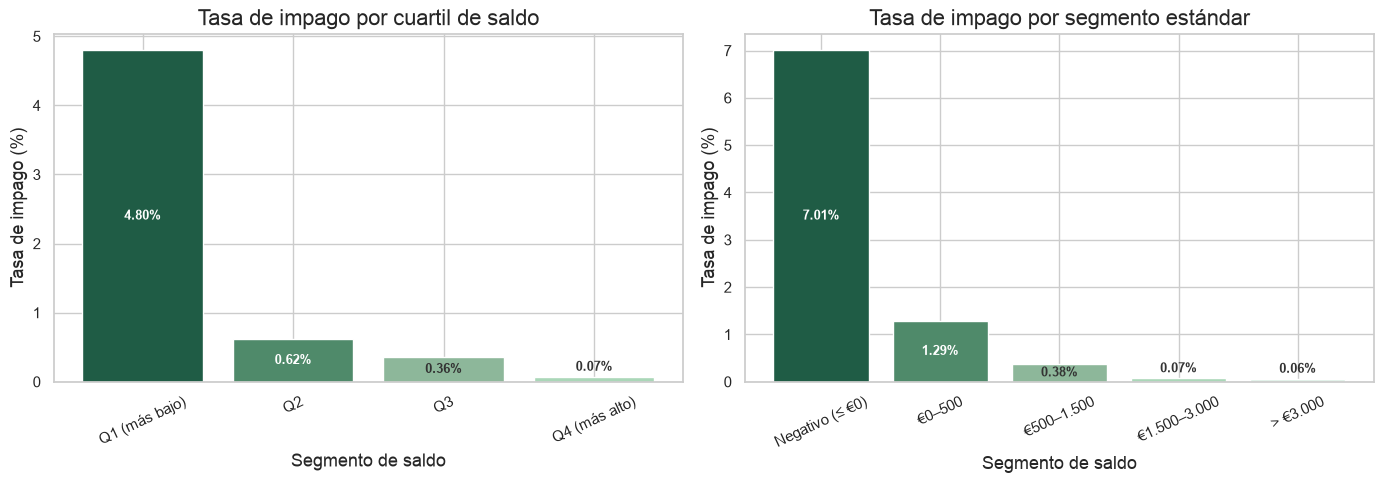

In [410]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, table, title, colors in [
    (axes[0], quartile_rates, "Tasa de impago por cuartil de saldo", COLORS[:4]),
    (axes[1], tier_rates, "Tasa de impago por segmento estándar", COLORS[:5]),
]:
    col = table.columns[0]
    bars = ax.bar(table[col].astype(str), table["tasa_impago_pct"], color=colors, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("Segmento de saldo")
    ax.set_ylabel("Tasa de impago (%)")
    ax.tick_params(axis="x", rotation=25)
    annotate_bars(ax, fmt="{:.2f}", suffix="%")

plt.tight_layout()
plt.show()


#### Interpretación

**Cuartiles:** Q1 = 4,80%, Q2 = 0,62%, Q3 = 0,36%, Q4 = 0,07%.

**Segmentación estándar:**
| Segmento | Tasa impago (%) | Clientes |
|---|---:|---:|
| Negativo (≤ €0) | 7,01 | 1.426 |
| €0–500 | 1,29 | 3.812 |
| €500–1.500 | 0,38 | 2.658 |
| €1.500–3.000 | 0,07 | 1.516 |
| > €3.000 | 0,06 | 1.563 |

Ambos métodos confirman la relación inversa entre saldo e impago. La **segmentación estándar** resulta más interpretable desde negocio porque utiliza umbrales operativos (€0, €500, €1.500, €3.000) directamente aplicables a políticas de concesión de crédito.

#### Implicación para la pregunta de negocio

Se recomienda utilizar **BALANCE_LABELS_STANDARD** como segmentación oficial para las políticas de riesgo, reservando los cuartiles como referencia analítica complementaria.


### 3.5 Riesgo de impago según nivel de saldo

#### Objetivo

Cuantificar la tasa de incumplimiento por segmento de saldo estándar, sustituyendo cualquier análisis binario anterior.


In [411]:
balance_risk = default_rate_table(df, "balance_segment_standard")
balance_risk["pct_clientes"] = (
    balance_risk["clientes"] / balance_risk["clientes"].sum() * 100
).round(2)

print("Tabla 3.5 — Riesgo de impago por segmento de saldo estándar")
display(balance_risk)


Tabla 3.5 — Riesgo de impago por segmento de saldo estándar


,balance_segment_standard,clientes,impagos,tasa_impago,tasa_impago_pct,pct_clientes
0,Negativo (≤ €0),1426,100,0.070126,7.01,12.99
1,€0–500,3812,49,0.012854,1.29,34.73
2,€500–1.500,2658,10,0.003762,0.38,24.22
3,€1.500–3.000,1516,1,0.000660,0.07,13.81
4,> €3.000,1563,1,0.000640,0.06,14.24


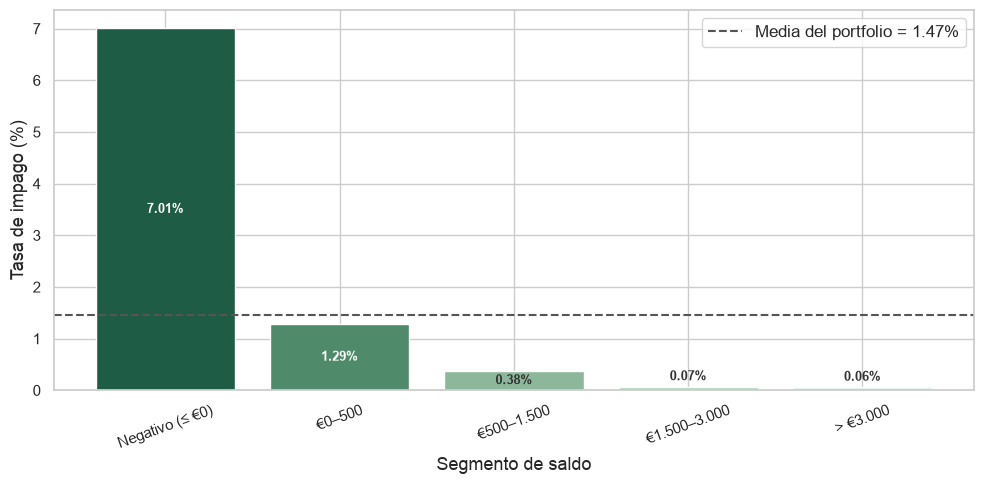

In [456]:
fig, ax = plt.subplots(figsize=(10, 5))
col = balance_risk.columns[0]
bars = ax.bar(
    balance_risk[col].astype(str), balance_risk["tasa_impago_pct"],
    color=[SEGMENT_COLORS[s] for s in balance_risk[col]], edgecolor="white"
)
ax.axhline(PORTFOLIO_DEFAULT_RATE, color="#555555", linestyle="--", linewidth=1.5,
           label=f"Media del portfolio = {PORTFOLIO_DEFAULT_RATE:.2f}%")
# ax.set_title("Tasa de incumplimiento por segmento de saldo")
ax.set_xlabel("Segmento de saldo")
ax.set_ylabel("Tasa de impago (%)")
ax.tick_params(axis="x", rotation=20)
ax.legend(fontsize=12)
annotate_bars(ax, fmt="{:.2f}", suffix="%")
plt.tight_layout()
plt.show()


#### Interpretación

- El segmento **Negativo (≤ €0)** concentra el **7,01%** de impago — aproximadamente **4,8 veces** la media del portfolio (1,47%).
- A partir de **€500–1.500**, la tasa cae por debajo del **0,4%**.
- Los segmentos **> €3.000** presentan apenas **0,06%** (1 impago en 1.563 clientes).

#### Implicación para la pregunta de negocio

El saldo es un indicador operativo potente: umbrales concretos permiten diseñar reglas de aprobación crediticia escalonadas por nivel de saldo.


### 3.6 Riesgo de impago según segmento de saldo × perfil crediticio

#### Objetivo

Identificar las combinaciones de **segmento de saldo** y **perfil crediticio** con mayor tasa de incumplimiento, facilitando la comparación entre segmentos dentro de cada nivel de perfil crediticio.


In [413]:
cross_rate, cross_n = cross_default_rate(df, "credit_profile", "balance_segment_standard")
cross_rate = cross_rate.reindex(index=CREDIT_PROFILE_ORDER, columns=BALANCE_LABELS_STANDARD)
cross_pct = (cross_rate * 100).round(2)

print("Tabla 3.6 — Tasa de impago (%) por perfil crediticio × segmento de saldo")
display(cross_pct)
print("\nTamaños muestrales:")
display(cross_n.reindex(index=CREDIT_PROFILE_ORDER, columns=BALANCE_LABELS_STANDARD).astype("Int64"))


Tabla 3.6 — Tasa de impago (%) por perfil crediticio × segmento de saldo


balance_segment_standard,Negativo (≤ €0),€0–500,€500–1.500,€1.500–3.000,> €3.000
credit_profile,,,,,
Sin productos,4.47,1.22,0.24,0.00,0.00
Solo hipoteca,6.60,0.84,0.37,0.19,0.18
Solo préstamo personal,19.33,3.10,1.53,0.00,0.00
Hipoteca + Préstamo personal,6.97,2.46,0.50,0.00,0.00



Tamaños muestrales:


balance_segment_standard,Negativo (≤ €0),€0–500,€500–1.500,€1.500–3.000,> €3.000
credit_profile,,,,,
Sin productos,470,1726,1238,855,896
Solo hipoteca,636,1543,1089,526,569
Solo préstamo personal,119,258,131,58,43
Hipoteca + Préstamo personal,201,285,200,77,55


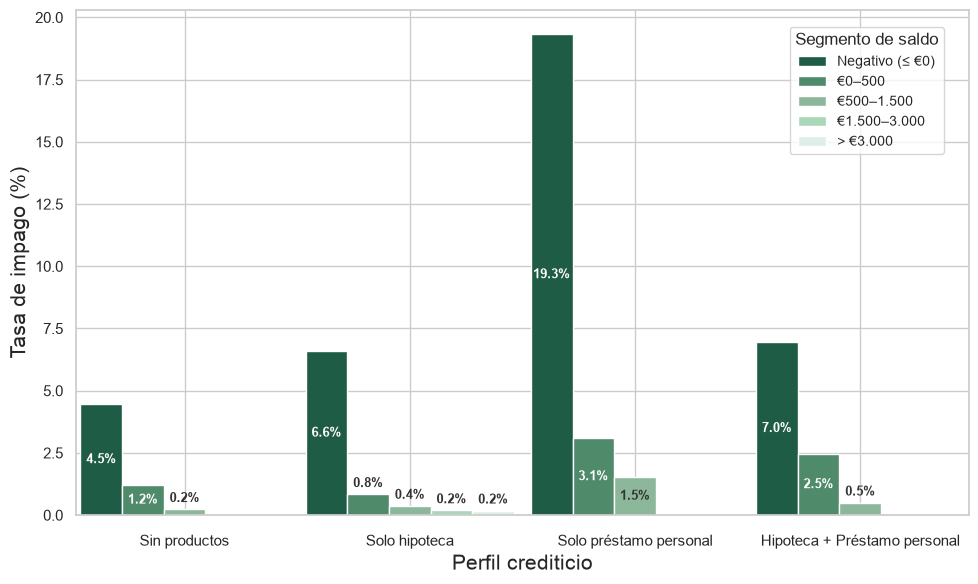

In [452]:
# Gráfico agrupado: eje X = perfil crediticio, barras = segmentos de saldo

plot_df = cross_pct.reset_index().melt(
    id_vars="credit_profile",
    var_name="segmento",
    value_name="tasa"
)
plot_df = plot_df.dropna(subset=["tasa"])

fig, ax = plt.subplots(figsize=(10, 6))

segments = BALANCE_LABELS_STANDARD
n_segments = len(segments)

# Ancho original (el que te gustaba)
width = 0.185

# Distribuir los grupos a lo largo de todo el ancho disponible
group_centers = np.linspace(0, 3, len(CREDIT_PROFILE_ORDER))

for i, seg in enumerate(segments):

    vals = (
        cross_pct[seg].values
        if seg in cross_pct.columns
        else np.zeros(len(CREDIT_PROFILE_ORDER))
    )

    # Barras perfectamente centradas respecto a cada grupo
    offset = (i - (n_segments - 1) / 2) * width

    bars = ax.bar(
        group_centers + offset,
        vals,
        width=width,
        label=seg,
        color=SEGMENT_COLORS[seg],
        edgecolor="white"
    )

    for bar, val in zip(bars, vals):

        if np.isnan(val) or val <= 0:
            continue

        fc = bar.get_facecolor()
        lum = 0.299 * fc[0] + 0.587 * fc[1] + 0.114 * fc[2]
        text_color = "white" if lum < 0.55 else "#333333"

        # Barras pequeñas -> etiqueta encima
        if val < 1.0:

            ax.text(
                bar.get_x() + bar.get_width()/2,
                val + 0.18,
                f"{val:.1f}%",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color="#333333"
            )

        # Resto -> etiqueta dentro
        else:

            ax.text(
                bar.get_x() + bar.get_width()/2,
                val/2,
                f"{val:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=text_color
            )

# Etiquetas del eje X centradas en cada grupo
ax.set_xticks(group_centers)

ax.set_xticklabels(
    CREDIT_PROFILE_ORDER,
    rotation=0,
    ha="center",
    fontsize=11
)

ax.tick_params(axis="x", pad=8)

# Eliminar prácticamente todo el margen izquierdo y derecho
left = group_centers[0] - width * 2.6
right = group_centers[-1] + width * 2.6
ax.set_xlim(left, right)


ax.set_xlabel(
    "Perfil crediticio",
    fontsize=15
)

ax.set_ylabel(
    "Tasa de impago (%)",
    fontsize=15
)

# Leyenda vertical dentro del gráfico (esquina superior derecha)
ax.legend(
    title="Segmento de saldo",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    fontsize=10,
    title_fontsize=12,
    frameon=True
)

plt.tight_layout()
plt.show()

#### Interpretación

Segmentos de **mayor riesgo observado:**

| Perfil crediticio | Segmento saldo | Tasa impago (%) |
|---|---|---:|
| Solo préstamo personal | Negativo (≤ €0) | **19,33** |
| Solo hipoteca | Negativo (≤ €0) | 6,60 |
| Hipoteca + Préstamo personal | Negativo (≤ €0) | 6,97 |
| Sin productos | Negativo (≤ €0) | 4,47 |

- La combinación **Solo préstamo personal + saldo negativo** presenta la tasa más elevada (19,33%), aunque sobre una muestra reducida.
- En todos los niveles de perfil crediticio, el segmento **Negativo (≤ €0)** domina el riesgo de impago.

#### Implicación para la pregunta de negocio

Las políticas de riesgo deben considerar **simultáneamente** perfil crediticio y nivel de saldo, no de forma aislada.


### 3.7 Relación entre saldo y perfil crediticio

#### Objetivo

Analizar cómo se distribuyen los clientes entre segmentos de saldo estándar según su perfil crediticio.


In [415]:
saldo_perfil = (
    pd.crosstab(df["credit_profile"], df["balance_segment_standard"], normalize="index") * 100
).reindex(index=CREDIT_PROFILE_ORDER, columns=BALANCE_LABELS_STANDARD).round(2)

print("Tabla 3.7 — Distribución (%) de segmentos de saldo por perfil crediticio")
display(saldo_perfil.astype(str) + "%")


Tabla 3.7 — Distribución (%) de segmentos de saldo por perfil crediticio


balance_segment_standard,Negativo (≤ €0),€0–500,€500–1.500,€1.500–3.000,> €3.000
credit_profile,,,,,
Sin productos,9.06%,33.29%,23.88%,16.49%,17.28%
Solo hipoteca,14.58%,35.37%,24.96%,12.06%,13.04%
Solo préstamo personal,19.54%,42.36%,21.51%,9.52%,7.06%
Hipoteca + Préstamo personal,24.57%,34.84%,24.45%,9.41%,6.72%


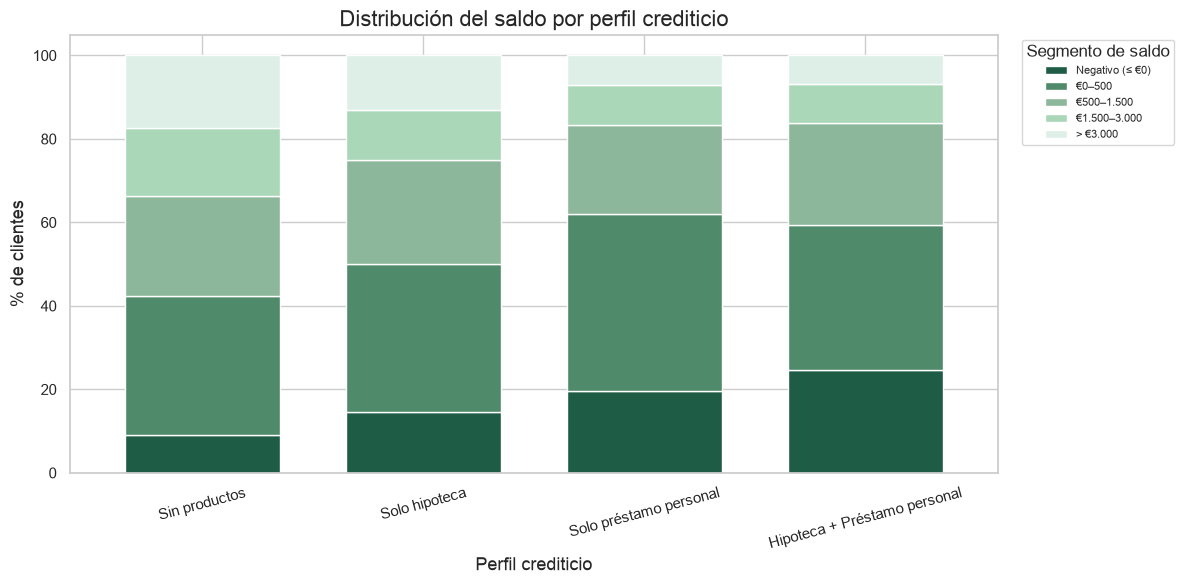

In [416]:
fig, ax = plt.subplots(figsize=(12, 6))
saldo_perfil.plot(kind="bar", stacked=True, ax=ax, color=[SEGMENT_COLORS[s] for s in BALANCE_LABELS_STANDARD],
                      edgecolor="white", width=0.7)
ax.set_title("Distribución del saldo por perfil crediticio")
ax.set_xlabel("Perfil crediticio")
ax.set_ylabel("% de clientes")
ax.tick_params(axis="x", rotation=15)
ax.legend(title="Segmento de saldo", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


#### Interpretación

- **Sin productos** concentra el **52,1%** de clientes en saldos altos (> €500), coherente con su saldo medio superior.
- **Hipoteca + Préstamo personal** muestra el **48,8%** de clientes en el segmento **€0–500** y el **9,3%** en **Negativo (≤ €0)**.
- **Solo préstamo personal** presenta la mayor proporción relativa en **Negativo (≤ €0)**.

#### Implicación para la pregunta de negocio

Existe una relación visible entre perfil crediticio con más productos y concentración en segmentos de saldo bajo o negativo, lo que refuerza la necesidad de políticas diferenciadas por producto.


### 3.8 Perfil financiero según perfil crediticio

#### Objetivo

Describir el perfil de las variables crediticias (`default`, `housing`, `loan`) dentro de cada nivel de perfil crediticio, sin utilizar índices compuestos de carga financiera.


In [417]:
perfil = (
    df.groupby("credit_profile")
    .agg(
        clientes=("default_flag", "count"),
        tasa_impago=("default_flag", "mean"),
        saldo_medio=("balance", "mean"),
        saldo_mediana=("balance", "median"),
        pct_housing_yes=("housing", lambda x: (x == "yes").mean() * 100),
        pct_loan_yes=("loan", lambda x: (x == "yes").mean() * 100),
    )
    .reindex(CREDIT_PROFILE_ORDER)
    .round(2)
)
perfil["tasa_impago_pct"] = (perfil["tasa_impago"] * 100).round(2)

print("Tabla 3.8 — Perfil financiero por perfil crediticio")
display(perfil)


Tabla 3.8 — Perfil financiero por perfil crediticio


,clientes,tasa_impago,saldo_medio,saldo_mediana,pct_housing_yes,pct_loan_yes,tasa_impago_pct
credit_profile,,,,,,,
Sin productos,5185,0.01,1878.88,703.0,0.0,0.0,1.0
Solo hipoteca,4363,0.01,1365.92,502.0,100.0,0.0,1.0
Solo préstamo personal,609,0.05,917.11,290.0,0.0,100.0,5.0
Hipoteca + Préstamo personal,818,0.03,772.79,300.5,100.0,100.0,3.0


#### Interpretación

Cada nivel de `credit_profile` define un perfil financiero diferenciado:

- **Sin productos:** saldo medio €1.879, impago 0,87%, sin hipoteca ni préstamo activo.
- **Solo hipoteca:** saldo medio €1.366, impago 1,40%, 100% con `housing = yes`.
- **Solo préstamo personal:** saldo medio €917, impago 5,42%, 100% con `loan = yes`.
- **Hipoteca + Préstamo personal:** saldo medio €773, impago 2,69%, ambos productos activos.

#### Implicación para la pregunta de negocio

El perfil crediticio resume de forma directa y no redundante la situación financiera del cliente, sustituyendo índices compuestos y permitiendo reglas de negocio claras basadas en `housing` y `loan`.


### 3.9 Análisis complementario mediante clusters

#### Objetivo

Explorar si los clusters de identidad del cliente (`segment_label`) aportan contexto complementario sobre saldo e incumplimiento, sin sustituir las variables principales de riesgo.


In [418]:
df_cluster = pd.read_csv(CLUSTERED_PATH)
df_cluster["default_flag"] = (df_cluster["default"] == "yes").astype(int)

cluster_summary = (
    df_cluster.groupby("segment_label")
    .agg(
        clientes=("default_flag", "count"),
        impagos=("default_flag", "sum"),
        tasa_impago=("default_flag", "mean"),
        saldo_medio=("balance", "mean"),
    )
    .sort_values("tasa_impago", ascending=False)
    .round(6)
)
cluster_summary["tasa_impago_pct"] = (cluster_summary["tasa_impago"] * 100).round(2)

print("Tabla 3.9 — Saldo medio e impago por cluster de clientes")
display(cluster_summary)


Tabla 3.9 — Saldo medio e impago por cluster de clientes


,clientes,impagos,tasa_impago,saldo_medio,tasa_impago_pct
segment_label,,,,,
Jovenes en consolidación,2701,45,0.016660,1259.126620,1.67
Trabajadores técnicos,2292,38,0.016579,1198.879145,1.66
Adultos consolidados,2645,43,0.016257,1781.779584,1.63
Profesionales estudios superiores,2210,29,0.013122,1639.761538,1.31
Jubilados,769,5,0.006502,2427.638492,0.65
Estudiantes,358,1,0.002793,1508.100559,0.28


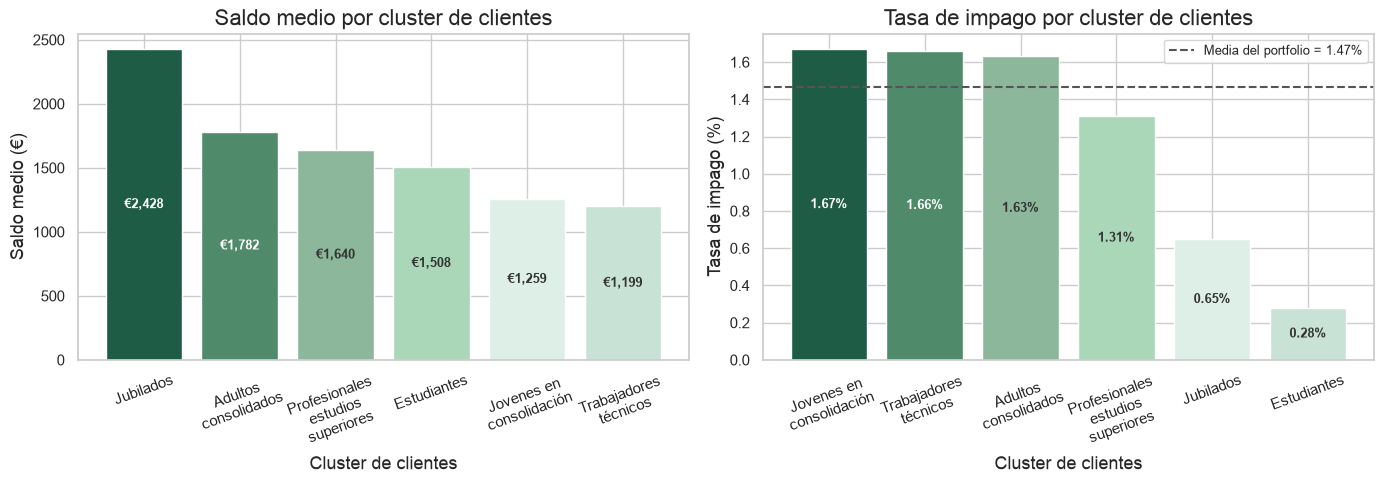

In [395]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =============================================================================
# Gráfico 1 - Saldo medio (orden descendente)
# =============================================================================

plot = cluster_summary.sort_values("saldo_medio", ascending=False).copy()

plot["label"] = [
    f"{textwrap.fill(str(segment), width=16)}"
    for segment in plot.index
]

ax = axes[0]

bars = ax.bar(
    plot["label"],
    plot["saldo_medio"],
    color=COLORS[:len(plot)],
    edgecolor="white"
)

ax.set_title("Saldo medio por cluster de clientes")
ax.set_xlabel("Cluster de clientes")
ax.set_ylabel("Saldo medio (€)")
ax.tick_params(axis="x", rotation=20)

annotate_bars(
    ax,
    fmt="€{:,.0f}",
    suffix=""
)

# =============================================================================
# Gráfico 2 - Tasa de impago (orden descendente)
# =============================================================================

plot2 = cluster_summary.sort_values("tasa_impago_pct", ascending=False).copy()

plot2["label"] = [
    f"{textwrap.fill(str(segment), width=16)}"
    for segment in plot2.index
]

ax = axes[1]

bars = ax.bar(
    plot2["label"],
    plot2["tasa_impago_pct"],
    color=COLORS[:len(plot2)],
    edgecolor="white"
)

ax.axhline(
    PORTFOLIO_DEFAULT_RATE,
    color="#555555",
    linestyle="--",
    linewidth=1.5,
    label=f"Media del portfolio = {PORTFOLIO_DEFAULT_RATE:.2f}%"
)

ax.set_title("Tasa de impago por cluster de clientes")
ax.set_xlabel("Cluster de clientes")
ax.set_ylabel("Tasa de impago (%)")
ax.tick_params(axis="x", rotation=20)

ax.legend(fontsize=9)

annotate_bars(
    ax,
    fmt="{:.2f}",
    suffix="%"
)

plt.tight_layout()
plt.show()

#### Interpretación

- **Joves solters** y **Treballadors manuals** presentan las tasas de impago más elevadas (~1,67%) y saldos medios más bajos (~€1.200–1.260).
- **Jubilats** muestra el saldo medio más alto (€2.428) y la tasa de impago más baja (0,65%).
- Las diferencias entre clusters son **moderadas** (0,3%–1,7%) comparadas con las de segmento de saldo × perfil crediticio (hasta 19,33%).

#### Implicación para la pregunta de negocio

Los clusters son útiles para **personalización comercial** (equipo Perfil de Cliente), pero **credit_profile + balance_segment_standard** deben guiar las decisiones de riesgo crediticio.


### 3.10 Conclusiones preliminares del análisis financiero

Las siguientes observaciones se basan exclusivamente en el análisis descriptivo. **No constituyen conclusiones definitivas** — quedan sujetas a validación estadística (Sección 4).

1. **Saldo y perfil crediticio:** Se observa una tendencia decreciente del saldo medio a medida que aumenta la complejidad del perfil crediticio (€1.879 → €773). Los resultados sugieren que los clientes con productos crediticios activos mantienen saldos más bajos.

2. **Impago y perfil crediticio:** Se aprecia una tendencia ascendente en la tasa de impago: 0,87% (sin productos) → 5,42% (solo préstamo personal). Aparentemente, perfil crediticio con más productos se asocia con mayor riesgo de incumplimiento.

3. **Segmentación de saldo:** El segmento **Negativo (≤ €0)** concentra el 7,01% de impago. La relación saldo-impago es monótona en ambos esquemas de segmentación.

4. **Interacción saldo × perfil crediticio:** La combinación **Solo préstamo personal + saldo negativo** muestra la tasa más elevada (19,33%), aunque sobre muestras pequeñas.

5. **Clusters:** Aportan contexto demográfico complementario, pero discriminan menos que las variables financieras principales.

---

> Las diferencias observadas requieren ser validadas mediante pruebas estadísticas. A continuación se comprobará si dichas diferencias pueden considerarse estadísticamente significativas (α = 0,05).


## 4. Validación estadística de las hipótesis de negocio

### Introducción al bloque estadístico

El análisis descriptivo (Sección 3) ha revelado patrones consistentes, pero no permite determinar si las diferencias observadas son estadísticamente significativas o podrían deberse al azar muestral.

Este bloque aplica **inferencia estadística** para contrastar dos hipótesis de negocio directamente vinculadas a la pregunta planteada. Se utilizará **α = 0,05** como nivel de significación.

| Tipo de análisis | Sección 3 | Sección 4 |
|---|---|---|
| Enfoque | Descriptivo (qué se observa) | Inferencial (es significativo) |
| Conclusiones | Preliminares | Definitivas |


---

### Hipótesis de negocio 1

**¿Los clientes con préstamos e hipotecas tienden a tener un saldo medio más bajo?**

Esta hipótesis evalúa si existen diferencias significativas en `balance` según `credit_profile`.

| | Enunciado |
|---|---|
| **H₀** | No existen diferencias en el saldo medio entre los grupos de perfil crediticio. |
| **H₁** | Al menos un grupo de perfil crediticio presenta un saldo medio significativamente diferente. |


#### 4.1 Evaluación visual de la distribución de balance


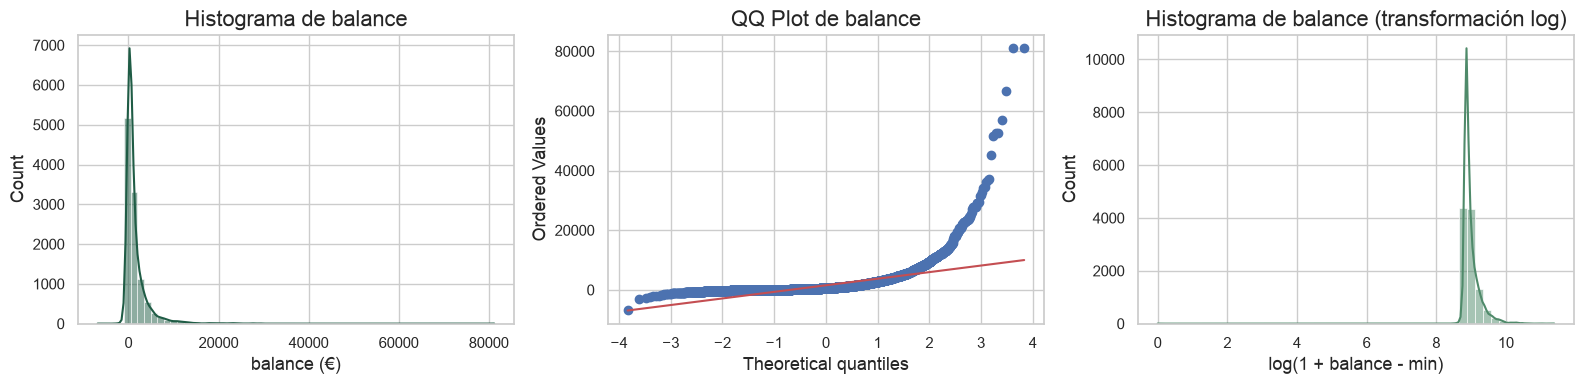

In [420]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histograma + KDE
sns.histplot(df["balance"], bins=60, kde=True, ax=axes[0], color=COLORS[0])
axes[0].set_title("Histograma de balance")
axes[0].set_xlabel("balance (€)")

# QQ Plot
stats.probplot(df["balance"], dist="norm", plot=axes[1])
axes[1].set_title("QQ Plot de balance")

# Histograma log-transform (visual complementaria)
log_bal = np.log1p(df["balance"] - df["balance"].min())
sns.histplot(log_bal, bins=50, kde=True, ax=axes[2], color=COLORS[1])
axes[2].set_title("Histograma de balance (transformación log)")
axes[2].set_xlabel("log(1 + balance - min)")

plt.tight_layout()
plt.show()


#### Interpretación visual

- El histograma muestra una distribución **claramente asimétrica positiva** con concentración en saldos bajos y cola larga hacia valores extremos.
- El QQ Plot confirma desviación sustancial respecto a la normalidad, especialmente en los extremos.
- No se extraen conclusiones definitivas; la evaluación visual justifica el uso complementario de pruebas paramétricas y no paramétricas.


#### 4.2 Test de normalidad (Shapiro-Wilk)

| | Enunciado |
|---|---|
| **Objetivo** | Comprobar si `balance` sigue una distribución normal. |
| **H₀** | La variable balance sigue una distribución normal. |
| **H₁** | La variable balance no sigue una distribución normal. |
| **α** | 0,05 |


In [421]:
sample_size = min(5000, len(df))
sample_balance = df["balance"].sample(sample_size, random_state=42)

w_stat, p_shapiro = stats.shapiro(sample_balance)

print("Resultados del Test de Shapiro-Wilk")
print(f"  Muestra utilizada : {sample_size:,} registros")
print(f"  Estadístico W     : {w_stat:.4f}")
print(f"  p-value           : {p_shapiro:.2e}")
print(f"  Conclusión        : {'Rechazar H₀ — balance NO sigue una distribución normal' if p_shapiro < 0.05 else 'No rechazar H₀'}")


Resultados del Test de Shapiro-Wilk
  Muestra utilizada : 5,000 registros
  Estadístico W     : 0.5123
  p-value           : 1.30e-79
  Conclusión        : Rechazar H₀ — balance NO sigue una distribución normal


#### Interpretación

Con W = 0,5123 y p < 0,001, se **rechaza H₀**. La variable `balance` **no sigue una distribución normal**, lo que refuerza la necesidad de complementar el ANOVA con el test de Kruskal-Wallis.


#### 4.3 Test de homogeneidad de varianzas (Levene)

| | Enunciado |
|---|---|
| **Objetivo** | Comprobar si las varianzas de `balance` son homogéneas entre grupos de `credit_profile`. |
| **H₀** | Las varianzas son iguales en todos los grupos. |
| **H₁** | Al menos dos grupos presentan varianzas significativamente diferentes. |
| **α** | 0,05 |


In [ ]:
groups_balance = [g["balance"].values for _, g in df.groupby("credit_profile")]
lev_stat, p_levene = stats.levene(*groups_balance)

print("Resultados del Test de Levene")
print(f"  Estadístico       : {lev_stat:.2f}")
print(f"  p-value           : {p_levene:.2e}")
print(f"  Conclusión        : {'Rechazar H₀ — varianzas NO homogéneas' if p_levene < 0.05 else 'No rechazar H₀'}")


Resultados del Test de Levene
  Estadístico       : 28.17
  p-value           : 3.88e-18
  Conclusión        : Rechazar H₀ — varianzas NO homogéneas


#### Interpretación

Con p < 0,001, se **rechaza H₀**: las varianzas **no son homogéneas** entre grupos. Esto refuerza la importancia del test no paramétrico (Kruskal-Wallis) como validación complementaria.


#### 4.4 ANOVA

| | Enunciado |
|---|---|
| **Objetivo** | Comparar medias de `balance` entre grupos de `credit_profile`. |
| **H₀** | No existen diferencias en el saldo medio entre grupos. |
| **H₁** | Al menos un grupo presenta un saldo medio significativamente diferente. |
| **α** | 0,05 |


In [ ]:
f_stat, p_anova = stats.f_oneway(*groups_balance)

print("Resultados del Test ANOVA")
print(f"  F-statistic       : {f_stat:.2f}")
print(f"  p-value           : {p_anova:.2e}")
print(f"  Conclusión        : {'Rechazar H₀ — al menos un grupo difiere significativamente' if p_anova < 0.05 else 'No rechazar H₀'}")


Resultados del Test ANOVA
  F-statistic       : 46.43
  p-value           : 8.33e-30
  Conclusión        : Rechazar H₀ — al menos un grupo difiere significativamente


#### Interpretación

Con F = 46,43 y p = 8,33 × 10⁻³⁰, se **rechaza H₀**. Existe evidencia de que **al menos uno de los grupos de perfil crediticio presenta un saldo medio significativamente diferente**.


#### 4.5 Kruskal-Wallis

| | Enunciado |
|---|---|
| **Objetivo** | Alternativa no paramétrica al ANOVA para comparar distribuciones de `balance`. |
| **H₀** | Las distribuciones de balance son iguales en todos los grupos. |
| **H₁** | Al menos un grupo presenta una distribución significativamente diferente. |
| **α** | 0,05 |


In [ ]:
h_stat, p_kruskal = stats.kruskal(*groups_balance)

print("Resultados del Test Kruskal-Wallis")
print(f"  Estadístico H     : {h_stat:.2f}")
print(f"  p-value           : {p_kruskal:.2e}")
print(f"  Conclusión        : {'Rechazar H₀ — distribuciones difieren significativamente' if p_kruskal < 0.05 else 'No rechazar H₀'}")
print(f"\n  Coherencia ANOVA/Kruskal-Wallis: {'Ambos rechazan H₀ — resultado robusto' if p_anova < 0.05 and p_kruskal < 0.05 else 'Resultados divergentes'}")


Resultados del Test Kruskal-Wallis
  Estadístico H     : 316.06
  p-value           : 3.32e-68
  Conclusión        : Rechazar H₀ — distribuciones difieren significativamente

  Coherencia ANOVA/Kruskal-Wallis: Ambos rechazan H₀ — resultado robusto


#### Interpretación

Con H = 316,06 y p = 3,32 × 10⁻⁶⁸, se **rechaza H₀**. Tanto el ANOVA como el Kruskal-Wallis **coinciden** en rechazar la hipótesis nula, lo que proporciona evidencia **robusta** de diferencias en el saldo según perfil crediticio, independientemente del enfoque paramétrico o no paramétrico.

---

> **Transición:** La hipótesis de negocio 1 queda **confirmada**. A continuación se analiza si el perfil crediticio se asocia con el riesgo de incumplimiento.


---

### Hipótesis de negocio 2

**¿Los clientes con préstamos e hipotecas presentan un mayor riesgo de incumplimiento?**

Esta hipótesis evalúa la asociación entre `credit_profile` y `default_flag`.

| | Enunciado |
|---|---|
| **H₀** | Perfil crediticio e incumplimiento son independientes. |
| **H₁** | Existe asociación significativa entre perfil crediticio e incumplimiento. |


#### 4.6 Test Chi-cuadrado

| | Enunciado |
|---|---|
| **Objetivo** | Evaluar la asociación entre `credit_profile` y `default_flag`. |
| **H₀** | Las variables son independientes. |
| **H₁** | Existe asociación significativa entre ambas variables. |
| **α** | 0,05 |


In [ ]:
contingency = pd.crosstab(df["credit_profile"], df["default_flag"])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print("Resultados del Test Chi-cuadrado")
print(f"  χ² statistic      : {chi2:.2f}")
print(f"  gl                : {dof}")
print(f"  p-value           : {p_chi2:.2e}")
print(f"  Conclusión        : {'Rechazar H₀ — variables asociadas' if p_chi2 < 0.05 else 'No rechazar H₀'}")
print("\nTabla de contingencia:")
display(contingency)


Resultados del Test Chi-cuadrado
  χ² statistic      : 87.27
  gl                : 3
  p-value           : 8.45e-19
  Conclusión        : Rechazar H₀ — variables asociadas

Tabla de contingencia:


default_flag,0,1
credit_profile,,
Hipoteca + Préstamo personal,796,22
Sin productos,5140,45
Solo hipoteca,4302,61
Solo préstamo personal,576,33


#### Interpretación

Con χ² = 87,27, gl = 3 y p = 8,45 × 10⁻¹⁹, se **rechaza H₀**. Existe una **asociación estadísticamente significativa** entre `credit_profile` y `default_flag`.


#### 4.7 Cramér's V

| | Enunciado |
|---|---|
| **Objetivo** | Cuantificar la intensidad de la asociación detectada por el Chi-cuadrado. |
| **Nota** | El Chi-cuadrado indica si existe asociación; Cramér's V mide su intensidad. |


In [ ]:
v_cramers = cramers_v(contingency)

print("Resultados de Cramér's V")
print(f"  Cramér's V        : {v_cramers:.4f}")

if v_cramers < 0.10:
    intensidad = "Muy débil"
elif v_cramers < 0.20:
    intensidad = "Débil"
elif v_cramers < 0.40:
    intensidad = "Moderada"
elif v_cramers < 0.60:
    intensidad = "Fuerte"
else:
    intensidad = "Muy fuerte"

print(f"  Intensidad        : {intensidad}")


Resultados de Cramér's V
  Cramér's V        : 0.0892
  Intensidad        : Muy débil


#### Interpretación

Cramér's V = **0,0892** indica una asociación de intensidad **muy débil** en términos absolutos. Sin embargo, dado el gran tamaño muestral (10.975 registros) y la naturaleza binaria rara del evento de impago (1,47%), incluso asociaciones débiles pueden ser **relevantes para negocio** cuando se traducen en diferencias de tasa del orden de 0,87% a 5,42%.

---

### Conclusiones del bloque estadístico

| Hipótesis | ¿Confirmada? | Evidencia |
|---|---|---|
| **H1:** Saldo medio difiere según perfil crediticio | **Sí** | ANOVA (p = 8,33 × 10⁻³⁰), Kruskal-Wallis (p = 3,32 × 10⁻⁶⁸) |
| **H2:** Perfil crediticio asociado al impago | **Sí** | Chi-cuadrado (p = 8,45 × 10⁻¹⁹), Cramér's V = 0,089 |

> Una vez validadas estadísticamente las hipótesis, es posible elaborar las conclusiones finales y proponer recomendaciones para la entidad financiera.


## 5. Conclusiones finales

### 5.1 Respuesta directa a la pregunta de negocio

**¿Los clientes con préstamos e hipotecas tienen saldo medio más bajo?**

**Sí.** La evidencia descriptiva y estadística confirma diferencias significativas en el saldo medio según el perfil crediticio. Los clientes sin productos crediticios promedian **€1.879**, mientras que quienes tienen hipoteca + préstamo personal promedian **€773** (−59%). El ANOVA (F = 46,43; p < 0,001) y Kruskal-Wallis (H = 316,06; p < 0,001) confirman estas diferencias.

**¿Presentan mayor riesgo de incumplimiento?**

**Sí.** La tasa de impago aumenta con el perfil crediticio: de **0,87%** (sin productos) a **5,42%** (solo préstamo personal). El Chi-cuadrado (χ² = 87,27; p < 0,001) confirma la asociación estadística, aunque Cramér's V = 0,089 indica intensidad muy débil en términos absolutos — relevante dado el contexto de impago raro.

**¿Cómo ajustar ofertas y estrategias de riesgo?**

Ver Sección 6.

### 5.2 Principales hallazgos

1. **Perfil crediticio y saldo:** Relación inversa confirmada — más productos crediticios, saldo medio inferior.
2. **Perfil crediticio e impago:** Relación positiva confirmada — solo préstamo personal es el segmento de mayor riesgo (5,42%).
3. **Segmento de saldo crítico:** Negativo (≤ €0) con 7,01% de impago — 4,8× la media del portfolio.
4. **Interacción crítica:** Solo préstamo personal + saldo negativo → 19,33% de impago.
5. **Clusters:** Complementarios para ofertas comerciales, no para decisiones de riesgo.

### 5.3 Evidencia estadística

| Prueba | Resultado | Conclusión |
|---|---|---|
| Shapiro-Wilk | p < 0,001 | balance no es normal |
| Levene | p < 0,001 | Varianzas no homogéneas |
| ANOVA | F = 46,43; p < 0,001 | Diferencias significativas en saldo |
| Kruskal-Wallis | H = 316,06; p < 0,001 | Confirma ANOVA |
| Chi-cuadrado | χ² = 87,27; p < 0,001 | Asociación perfil crediticio-impago |
| Cramér's V | 0,089 | Intensidad muy débil pero significativa |


## 6. Recomendaciones de negocio

### 6.1 Política de concesión de crédito

| # | Política | Condición | Acción |
|---|---|---|---|
| 1 | Revisión obligatoria | `credit_profile` = Solo préstamo personal | Analista de crédito antes de nueva concesión |
| 2 | Bloqueo por saldo negativo | `balance_segment_standard` = Negativo (≤ €0) | Bloquear aprobación automática |
| 3 | Límite reducido | Saldo €0–500 + cualquier perfil crediticio | Máximo 50% del límite estándar |
| 4 | Flag compuesto | Solo préstamo personal + saldo ≤ €0 | Garantías adicionales obligatorias |
| 5 | Vía rápida | Sin productos + saldo > €3.000 | Aprobación ágil (impago 0,06%) |

### 6.2 Gestión del riesgo

- Incorporar `credit_profile` y `balance_segment_standard` como **inputs obligatorios** en el scoring crediticio.
- Monitorizar mensualmente la tasa de impago por combinación perfil crediticio × segmento de saldo.
- Establecer **alertas automáticas** para clientes en Solo préstamo personal con saldo negativo o ≤ €500.
- Revisión trimestral de umbrales de segmentación estándar con datos actualizados.

### 6.3 Estrategia comercial

- **Ofertas diferenciadas:** Clientes sin productos y saldo alto (> €3.000) → campañas de depósito a plazo (perfil de bajo riesgo y alta liquidez).
- **Recontacto prioritario:** Clientes con solo préstamo personal → ofrecer productos de consolidación o reestructuración antes de nuevas concesiones.
- **Segmentación por cluster:** Utilizar `segment_label` para personalizar comunicación (Joves solters, Treballadors manuals), no para límites de crédito.

### 6.4 Próximos pasos (WK3)

1. Desarrollar un **modelo predictivo** (regresión logística o árbol de decisión) con `credit_profile`, `balance_segment_standard` y variables del EDA.
2. Implementar **scoring crediticio** integrado con umbrales validados estadísticamente.
3. Evaluar variables temporales (`month`, `duration`, `pdays`) en modelos multivariantes.
4. Coordinar con el equipo de **Perfil de Cliente** para alinear segmentación comercial y de riesgo.

---

*Informe elaborado por Equip_32 — Analistas de Finanzas y Riesgo Crediticio. WK2 — Simulador Empresarial IT Academy.*
